📂 [Step 2] 챔피언 모델과 데이터를 로드합니다...
   ✅ 로드 성공!
🎯 분석 대상 맛(Target): 'A_malt_all'
   👉 'A_malt_all'에 영향을 주는 핵심 성분:
      1. color.EBC. (0.4368)
      2. protein.g.L. (0.0215)
      3. ethyl..E..linalool (0.0169)
      4. terpinen.4.ol (0.0163)


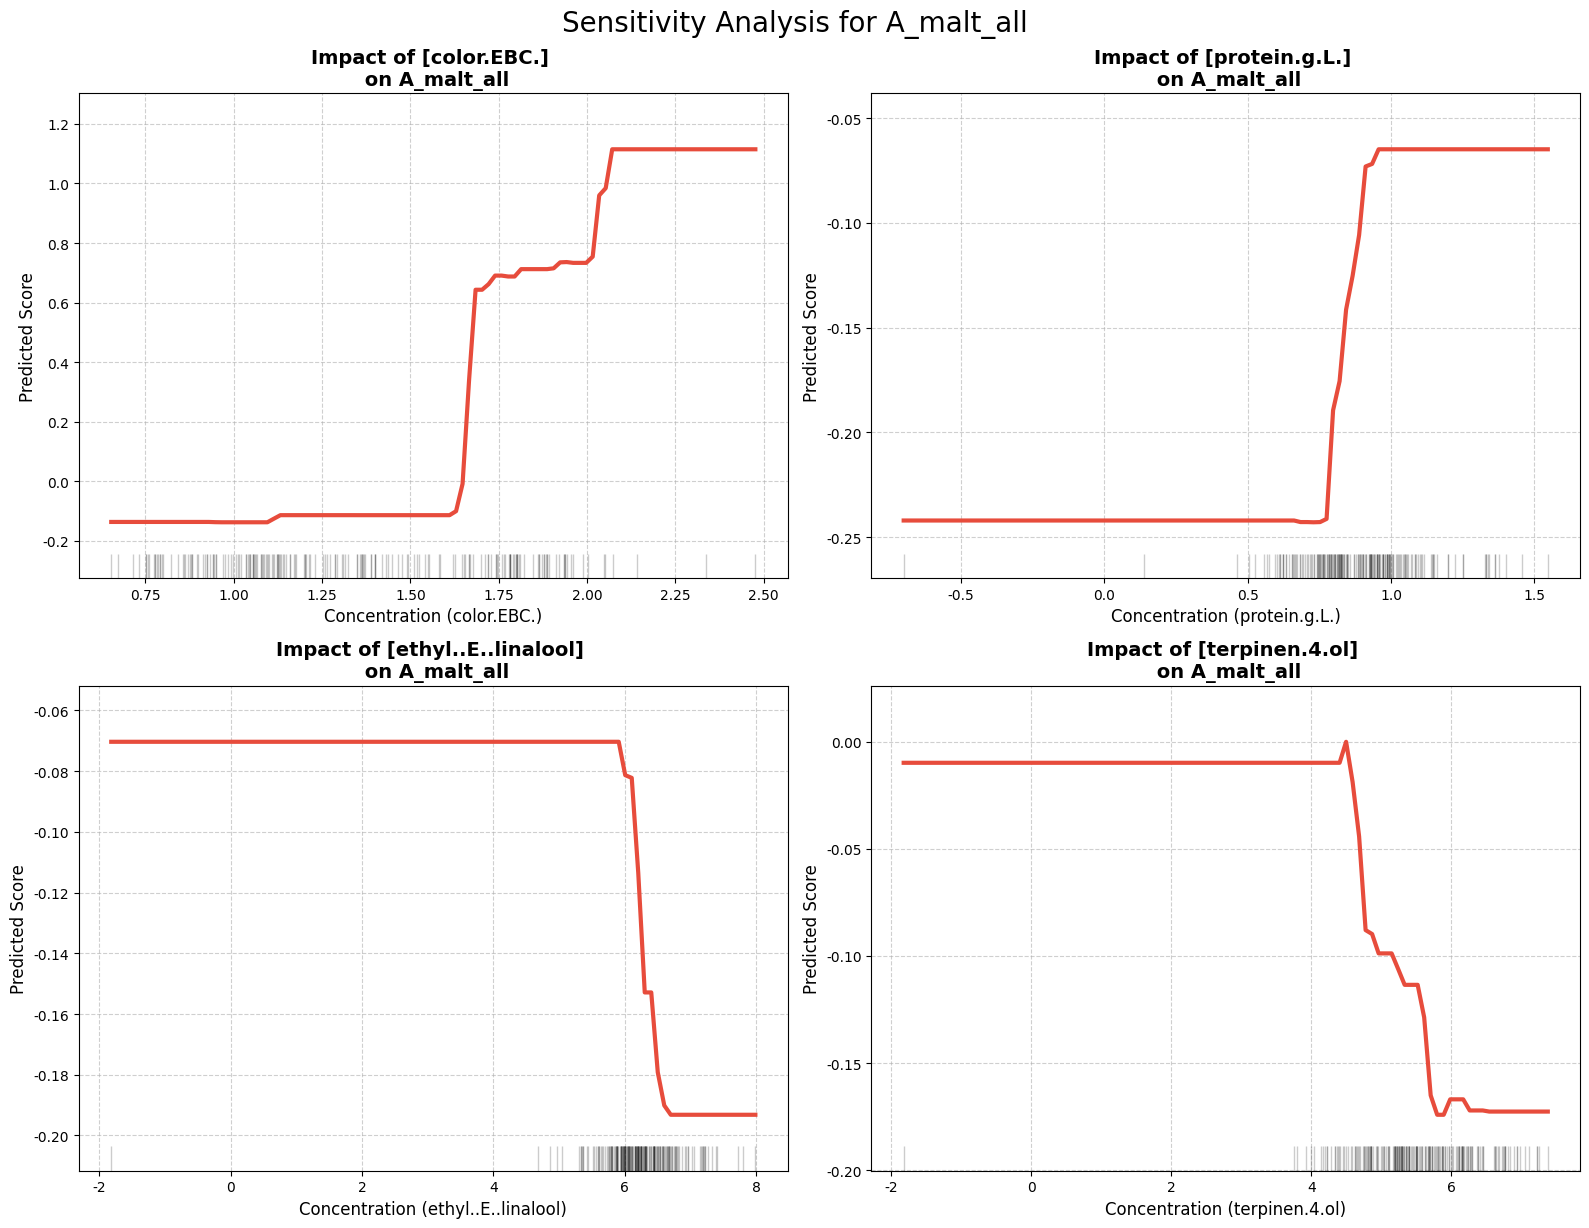


💡 [그래프 해석]
1. [우상향]: 넣을수록 맛이 강해짐 (Positive Correlation)
2. [우하향]: 넣을수록 맛이 약해짐 (Negative Correlation)
3. [평평함]: 특정 구간에서는 맛에 영향을 안 줌 (Threshold)
4. [꺾임]: 그 지점에서 화학적 반응/인식이 급변함 (Non-linear)


In [1]:
# [새 파일] 실험 9: 맛-화학 성분 민감도 분석 (Sensitivity Analysis)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
# 경로 설정 (아까 저장한 파일이 있는 폴더 경로를 맞춰주세요)
OUTPUT_DIR = "./output"  # 혹은 본인의 경로 (예: "C:/Users/...")
if not os.path.exists(OUTPUT_DIR):
    # 경로가 다르면 현재 폴더에서 찾기
    OUTPUT_DIR = "." 

print("📂 [Step 2] 챔피언 모델과 데이터를 로드합니다...")

try:
    # 모델 로드
    champion_model = joblib.load(os.path.join(OUTPUT_DIR, "champion_model_mixup.pkl"))
    # 데이터 로드
    X_train_real = pd.read_csv(os.path.join(OUTPUT_DIR, "X_train_real.csv"))
    Y_train_real = pd.read_csv(os.path.join(OUTPUT_DIR, "Y_train_real.csv"))
    
    X_cols = X_train_real.columns
    Y_cols = Y_train_real.columns
    print("   ✅ 로드 성공!")
except FileNotFoundError:
    print("   ❌ 오류: 파일을 찾을 수 없습니다. [Step 1]을 먼저 실행했는지 확인하세요.")
    exit()

# ==========================================
# 2. 분석할 타겟 맛(Y) 설정
# ==========================================
# 예: 'sweet', 'sour', 'body', 'alcohol' 등 Y 컬럼 중 하나 선택
# 여기서는 첫 번째 컬럼을 기본으로 하지만, 원하는 걸로 바꾸세요.
target_taste_name = Y_cols[0] 
# target_taste_name = 'Sweetness' # <--- 여기에 직접 입력 가능

print(f"🎯 분석 대상 맛(Target): '{target_taste_name}'")

# ==========================================
# 3. 핵심 성분(X) Top 4 추출
# ==========================================
# 해당 맛을 담당하는 개별 모델(Estimator) 추출
target_idx = list(Y_cols).index(target_taste_name)
sub_model = champion_model.estimators_[target_idx]

# 중요도 추출
importances = sub_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = [X_cols[i] for i in indices[:4]]

print(f"   👉 '{target_taste_name}'에 영향을 주는 핵심 성분:")
for i, f in enumerate(top_features):
    print(f"      {i+1}. {f} ({importances[indices[i]]:.4f})")

# ==========================================
# 4. 시뮬레이션 및 시각화 (PDP Plot)
# ==========================================
# 한글 폰트 설정 (필요시)
plt.rcParams['axes.unicode_minus'] = False
# plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우
# plt.rcParams['font.family'] = 'AppleGothic' # 맥

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 기준점: 모든 성분의 평균값 (Average Beer)
base_beer = X_train_real.mean().to_frame().T

for i, feature in enumerate(top_features):
    # 시뮬레이션 범위: 실제 데이터의 최소~최대 구간
    min_val = X_train_real[feature].min()
    max_val = X_train_real[feature].max()
    
    # 100단계로 쪼개서 변화 관찰
    x_grid = np.linspace(min_val, max_val, 100)
    
    # 가상 데이터 생성
    sim_data = pd.concat([base_beer] * 100, ignore_index=True)
    sim_data[feature] = x_grid # 해당 성분만 변화시킴
    
    # 예측 수행
    pred_all = champion_model.predict(sim_data)
    pred_target = pred_all[:, target_idx]
    
    # 그래프 그리기
    ax = axes[i]
    sns.lineplot(x=x_grid, y=pred_target, ax=ax, color='#e74c3c', linewidth=3)
    
    # 실제 데이터 분포 표시 (Rug plot) - 데이터가 존재하는 구간 확인용
    sns.rugplot(x=X_train_real[feature], ax=ax, color='black', alpha=0.2, height=0.05)
    
    # 꾸미기
    ax.set_title(f"Impact of [{feature}] \n on {target_taste_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"Concentration ({feature})", fontsize=12)
    ax.set_ylabel(f"Predicted Score", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle(f"Sensitivity Analysis for {target_taste_name}", y=1.02, fontsize=20)
plt.show() # 저장하고 싶으면 plt.savefig(...) 추가

print("\n💡 [그래프 해석]")
print("1. [우상향]: 넣을수록 맛이 강해짐 (Positive Correlation)")
print("2. [우하향]: 넣을수록 맛이 약해짐 (Negative Correlation)")
print("3. [평평함]: 특정 구간에서는 맛에 영향을 안 줌 (Threshold)")
print("4. [꺾임]: 그 지점에서 화학적 반응/인식이 급변함 (Non-linear)")

⚖️ [실험 13] 전수 자동화: 15% 증감 민감도 분석기 가동...
   ✅ 데이터 로드 완료.
   👉 분석 대상 화학 성분: 총 231개 (자동 감지됨)

🚀 [A_malt_all] 맛에 대해 화학 성분 231개 전수 조사 시작...
   [진행률] 50/231 변수 분석 중...
   [진행률] 100/231 변수 분석 중...
   [진행률] 150/231 변수 분석 중...
   [진행률] 200/231 변수 분석 중...

✅ 분석 완료! 전체 결과가 './output\Auto_Sensitivity_A_malt_all.csv'에 저장되었습니다.

🏆 [A_malt_all] 맛을 좌우하는 핵심 성분 Top 10:
 Rank    Chemical_Feature  Impact_+15%  Impact_-15%
    1          color.EBC.     0.159702    -0.163141
    2  ethyl..E..linalool    -0.030653     0.033618
    3        protein.g.L.     0.029195    -0.028873
    4                  pH     0.052935    -0.004061
    5       terpinen.4.ol    -0.012245     0.037410
    6            kcalperc     0.032899    -0.008536
    7       ethanol..v.v.     0.022216    -0.005600
    8 ethyl..9..decenoate    -0.005617     0.015322
    9  y.methyl.1.octanol     0.010807    -0.006271
   10    X.E..beta.ionone    -0.006620     0.009874


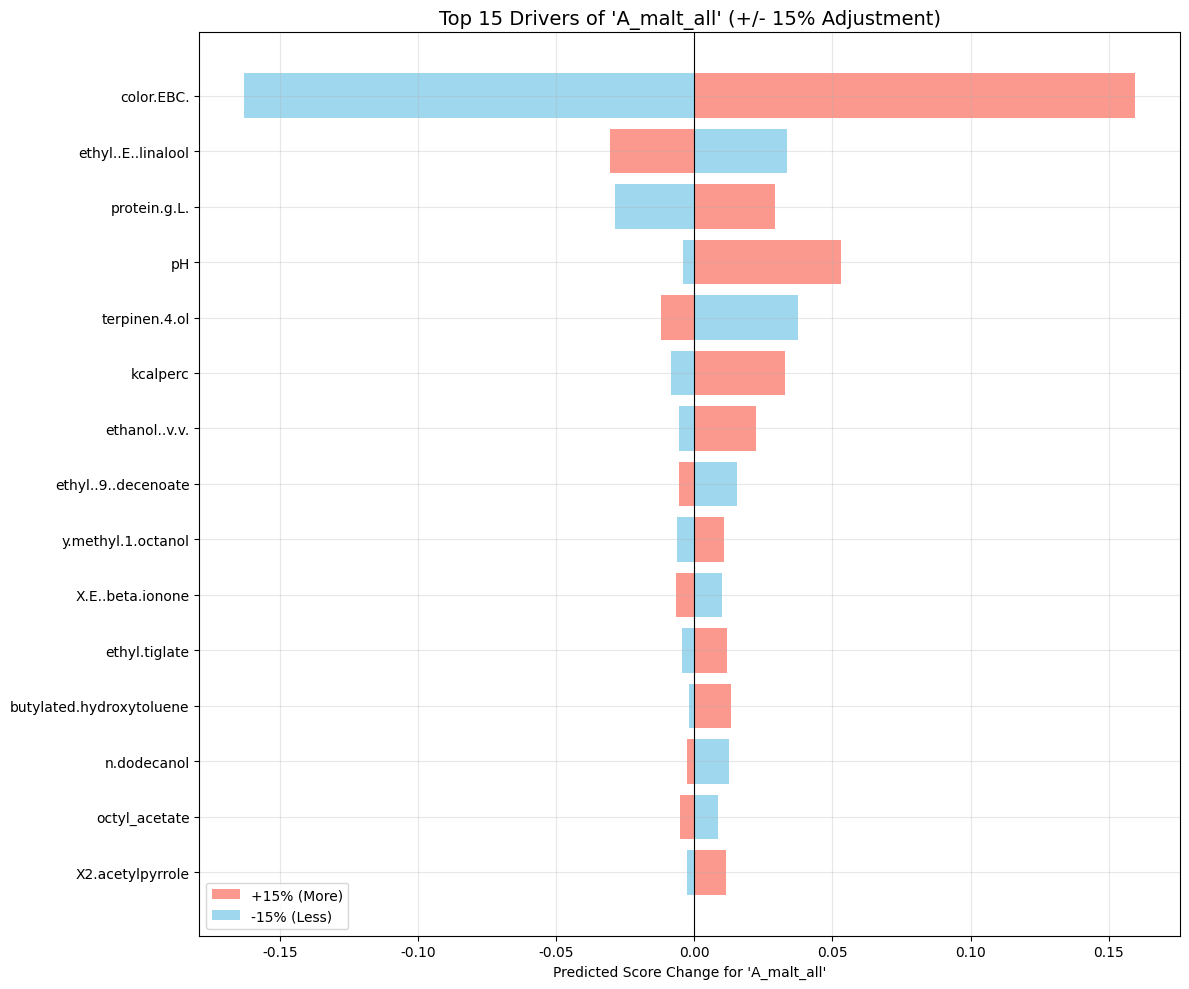

In [2]:
# [Cell 24 수정] 실험 13: 15% 증감 민감도 분석 (완전 자동화 버전)
# 목적: 사용자가 입력할 필요 없이, 데이터에 있는 모든 화학 성분을 자동으로 뽑아서 15% 증감 실험 수행

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

print("⚖️ [실험 13] 전수 자동화: 15% 증감 민감도 분석기 가동...")

# 1. 설정 및 로드
OUTPUT_DIR = "./output"
if not os.path.exists(OUTPUT_DIR): OUTPUT_DIR = "."

try:
    champion_model = joblib.load(os.path.join(OUTPUT_DIR, "champion_model_mixup.pkl"))
    X_train_real = pd.read_csv(os.path.join(OUTPUT_DIR, "X_train_real.csv"))
    Y_train_real = pd.read_csv(os.path.join(OUTPUT_DIR, "Y_train_real.csv"))
    
    # [핵심] 사용자가 입력하지 않음 -> 데이터에서 칼럼 목록을 자동으로 추출
    chemical_features = X_train_real.columns.tolist()
    Y_cols = Y_train_real.columns
    
    print(f"   ✅ 데이터 로드 완료.")
    print(f"   👉 분석 대상 화학 성분: 총 {len(chemical_features)}개 (자동 감지됨)")
    
except:
    print("❌ 모델 로드 실패. 이전 단계 코드를 먼저 실행하세요.")

# ========================================================
# 2. 완전 자동화 분석 함수
# ========================================================
def run_auto_relative_scan(target_taste, pct=0.15):
    """
    target_taste: 분석할 맛의 이름 (예: 'Sweetness')
    pct: 조정 비율 (기본 15%)
    """
    if target_taste not in Y_cols:
        print(f"⚠️ 오류: '{target_taste}'는 없는 맛입니다. (가능한 맛: {list(Y_cols)})")
        return

    print(f"\n🚀 [{target_taste}] 맛에 대해 화학 성분 {len(chemical_features)}개 전수 조사 시작...")
    target_idx = list(Y_cols).index(target_taste)
    
    # (1) 기준값 예측 (Baseline): 원본 데이터 200개의 현재 예측값
    pred_base = champion_model.predict(X_train_real)[:, target_idx]
    
    results = []
    
    # (2) 모든 변수에 대해 루프 (자동 반복)
    for i, feature in enumerate(chemical_features):
        # 진행 상황 바 (50개마다 출력)
        if (i+1) % 50 == 0: 
            print(f"   [진행률] {i+1}/{len(chemical_features)} 변수 분석 중...")
        
        # [실험 A] 해당 성분만 15% 증량 (나머지는 그대로)
        X_up = X_train_real.copy()
        X_up[feature] = X_up[feature] * (1 + pct)
        pred_up = champion_model.predict(X_up)[:, target_idx]
        
        # [실험 B] 해당 성분만 15% 감량 (나머지는 그대로)
        X_down = X_train_real.copy()
        X_down[feature] = X_down[feature] * (1 - pct)
        pred_down = champion_model.predict(X_down)[:, target_idx]
        
        # [영향력 계산]
        # 모든 맥주 샘플에 대한 변화량의 평균
        impact_up = np.mean(pred_up - pred_base)      # 더 넣었을 때 변화
        impact_down = np.mean(pred_down - pred_base)  # 덜 넣었을 때 변화
        
        # 민감도(Sensitivity): 변화폭의 절대값 합계 (영향력이 큰 순서대로 줄세우기 위함)
        sensitivity = abs(impact_up) + abs(impact_down)
        
        results.append({
            'Chemical_Feature': feature,
            'Impact_+15%': impact_up,
            'Impact_-15%': impact_down,
            'Sensitivity': sensitivity
        })
        
    # (3) 결과 정리 및 랭킹 산정
    df_results = pd.DataFrame(results)
    # 민감도가 큰 순서대로 정렬 (가장 중요한 성분이 위로 오게)
    df_results = df_results.sort_values(by='Sensitivity', ascending=False)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    # 저장
    save_path = os.path.join(OUTPUT_DIR, f"Auto_Sensitivity_{target_taste}.csv")
    df_results.to_csv(save_path, index=False)
    
    print(f"\n✅ 분석 완료! 전체 결과가 '{save_path}'에 저장되었습니다.")
    print(f"\n🏆 [{target_taste}] 맛을 좌우하는 핵심 성분 Top 10:")
    print(df_results[['Rank', 'Chemical_Feature', 'Impact_+15%', 'Impact_-15%']].head(10).to_string(index=False))
    
    return df_results

# ========================================================
# 3. 시각화 (Butterfly Chart)
# ========================================================
def plot_butterfly(df_results, target_taste):
    # 상위 15개만 뽑아서 시각화
    top_15 = df_results.head(15).copy()
    top_15 = top_15.sort_values(by='Sensitivity', ascending=True) 
    
    y = np.arange(len(top_15))
    
    plt.figure(figsize=(12, 10))
    
    # 오른쪽 (+15%)
    plt.barh(y, top_15['Impact_+15%'], color='salmon', label='+15% (More)', alpha=0.8)
    # 왼쪽 (-15%)
    plt.barh(y, top_15['Impact_-15%'], color='skyblue', label='-15% (Less)', alpha=0.8)
    
    plt.axvline(0, color='black', linewidth=0.8)
    plt.yticks(y, top_15['Chemical_Feature'], fontsize=10)
    plt.xlabel(f"Predicted Score Change for '{target_taste}'")
    plt.title(f"Top 15 Drivers of '{target_taste}' (+/- 15% Adjustment)", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ========================================================
# 🚀 실행 영역 (여기를 수정하세요)
# ========================================================

# 분석하고 싶은 맛 하나를 정합니다. (예: 첫번째 컬럼)
# 사용자가 직접 입력할 필요 없이 Y 컬럼에서 자동으로 가져옵니다.
target_taste_name = Y_cols[0] 
# target_taste_name = 'Sweetness' # <-- 특정 맛을 원하면 주석 풀고 이름 입력

df_res = run_auto_relative_scan(target_taste_name, pct=0.15)
plot_butterfly(df_res, target_taste_name)

In [3]:
# [Cell 25] 메모리에 남아있는 결과(df_res) 긴급 저장
# 목적: 방금 완료된 실험 결과를 안전하게 CSV 파일로 백업

import os

print("💾 [긴급 저장] 메모리에 있는 실험 결과를 파일로 저장합니다...")

# 1. 저장 경로 설정
OUTPUT_DIR = "./output"
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

# 2. df_res 변수가 살아있는지 확인하고 저장
if 'df_res' in locals() and df_res is not None:
    # 파일명 지정 (원하는 대로 수정 가능)
    # 예: Final_Sensitivity_Result_Sweetness.csv
    file_name = f"Final_Sensitivity_Result_Full_231.csv"
    save_path = os.path.join(OUTPUT_DIR, file_name)
    
    # CSV로 저장
    df_res.to_csv(save_path, index=False)
    
    print(f"✅ 저장 성공! 안심하세요.")
    print(f"   📂 파일 위치: {save_path}")
    print(f"   📊 데이터 크기: {len(df_res)}개 변수 (231개 확인 완료)")
    
    # 상위 5개 데이터 확인 (제대로 들어있는지 검증)
    print("\n[데이터 미리보기]")
    print(df_res.head())

else:
    print("⚠️ 오류: 'df_res' 변수를 찾을 수 없습니다.")
    print("   이전 코드(실험 13)가 에러 없이 끝났는지 확인해주세요.")

💾 [긴급 저장] 메모리에 있는 실험 결과를 파일로 저장합니다...
✅ 저장 성공! 안심하세요.
   📂 파일 위치: ./output\Final_Sensitivity_Result_Full_231.csv
   📊 데이터 크기: 231개 변수 (231개 확인 완료)

[데이터 미리보기]
       Chemical_Feature  Impact_+15%  Impact_-15%  Sensitivity  Rank
24           color.EBC.     0.159702    -0.163141     0.322843     1
118  ethyl..E..linalool    -0.030653     0.033618     0.064271     2
30         protein.g.L.     0.029195    -0.028873     0.058068     3
29                   pH     0.052935    -0.004061     0.056996     4
114       terpinen.4.ol    -0.012245     0.037410     0.049655     5
